# Week 2 · Distribution Shape, Missing Data, Outliers & Transformations
*DS 207 · Week 2*

## Assignment Overview

**Topic:** Distribution shape and skewness; missing data, outliers, and transformations
**Business scenario:** BayaniFund Microfinance, a Cebu-based lending fintech. RJ Bautista, Head of Credit Risk, is preparing loan-applicant data for an automated credit-scoring model and needs the data diagnosed and cleaned before it can be trusted.

EC Corro, built in collaboration with Claude, ChatGPT, and Gemini.

### Submission Instructions

- File name: `ds207_02_shape_missingness_outliers_<lastname>.ipynb`
- Submit to your shared Google Drive folder.
- Due 11:59 PM the day after the associated session.

### AI Use Policy

Generative AI tools are allowed for concept clarification, pseudocode, debugging, and idea generation. You must be able to explain any submitted answer without relying on an AI tool, and you must cite any AI use per course policy.

### Point Breakdown

Section 1 (30 pts) + Section 2 (30 pts) = **60 pts total**

## Dataset

Run the cell below to generate this assignment's applicant batch. It uses the same generating process introduced in this week's lecture notes, plus one additional field, `months_employed_reported`, that has its own missingness pattern for you to diagnose in Section 1.

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(207)

n = 400

employment_type = rng.choice(["Formal", "Informal"], size=n, p=[0.4, 0.6])

mu = np.where(employment_type == "Formal", np.log(18000), np.log(13000))
sigma = np.where(employment_type == "Formal", 0.35, 0.45)
monthly_income_php = rng.lognormal(mean=mu, sigma=sigma)
monthly_income_php = np.round(monthly_income_php, -1)

months_employed = rng.integers(3, 121, size=n).astype(float)
loan_amount_requested_php = np.round(monthly_income_php * rng.uniform(0.8, 2.5, size=n), -2)
applicant_id = np.array([f"BF{2207 + i:05d}" for i in range(n)])

applicants = pd.DataFrame({
    "applicant_id": applicant_id,
    "employment_type": employment_type,
    "months_employed": months_employed,
    "monthly_income_php": monthly_income_php,
    "loan_amount_requested_php": loan_amount_requested_php,
})

miss_prob = np.where(applicants["employment_type"] == "Informal", 0.32, 0.06)
missing_mask = rng.random(n) < miss_prob
applicants.loc[missing_mask, "monthly_income_php"] = np.nan

non_missing_idx = applicants.index[applicants["monthly_income_php"].notna()]
entry_error_idx = rng.choice(non_missing_idx, size=4, replace=False)
applicants.loc[entry_error_idx, "monthly_income_php"] *= 10
remaining_idx = np.setdiff1d(non_missing_idx, entry_error_idx)
fraud_idx = rng.choice(remaining_idx, size=3, replace=False)
applicants.loc[fraud_idx, "monthly_income_php"] = rng.uniform(280000, 400000, size=3).round(-1)

# Additional field for this assignment: months employed, with its own
# missingness pattern for you to diagnose in Section 1, Item 2.
months_missing_mask = rng.random(n) < 0.08
applicants["months_employed_reported"] = applicants["months_employed"]
applicants.loc[months_missing_mask, "months_employed_reported"] = np.nan

applicants.head()

,applicant_id,employment_type,months_employed,monthly_income_php,loan_amount_requested_php,months_employed_reported
0,BF02207,Formal,55.0,165500.0,26500.0,55.0
1,BF02208,Informal,5.0,NaN,19800.0,5.0
2,BF02209,Informal,72.0,6420.0,8500.0,72.0
3,BF02210,Informal,81.0,29440.0,42800.0,81.0
4,BF02211,Informal,58.0,NaN,18000.0,58.0


## Section 1: Concepts, Computation & Coding

Each item below is one integrated problem with three labeled parts: a short conceptual question, a by-hand computation on a small extract of data, and a coding task that verifies your by-hand work at full scale. Show your work for part (b) in a markdown cell.

### Item 1 — Distribution Shape of Requested Loan Amounts (10 pts)

BayaniFund's `loan_amount_requested_php` column has not yet been examined this week. RJ wants to know whether it shares the same shape problem as monthly income.

**(a) Concept (3 pts).** In two to three sentences, explain why you would expect requested loan amounts to be right-skewed for a similar underlying reason as monthly income, even before looking at the data.

**(b) By hand (4 pts).** Four hypothetical requested loan amounts (PHP): $15{,}000,\ 18{,}000,\ 20{,}000,\ 55{,}000$. Compute the mean, then compute the sample skewness using the adjusted Fisher–Pearson formula from lecture:

$$G_1 = \frac{\sqrt{n(n-1)}}{n-2}\cdot\frac{m_3}{m_2^{3/2}}, \qquad m_k = \frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^k$$

Show the mean, the deviations from the mean, $m_2$, $m_3$, and the final $G_1$ value.

**(c) Code (3 pts).** Using `applicants["loan_amount_requested_php"]`, compute the skewness, excess kurtosis, and a Shapiro-Wilk test statistic and p-value at full scale. Plot a histogram with the mean and median marked. Verify your part (b) result matches `scipy.stats.skew` on the four-point example before moving to full scale.

---
a. Most applicants will request loans that are modest and aligned with their ability to repay, but a smaller group will request unusually large amounts. That creates a long right tail, just like income distributions, where the amjority cluster near typical values but a few extreme cases stretch the average upward. 

---
b.
- Mean: $\bar{x} = \dfrac{15000 + 18000 + 20000 + 55000}{4} = 27{,}000$
- Deviations from the mean: $-12000,\ -9000,\ -7000,\ 28000$
- $m_2 = \dfrac{(-12000)^2+(-9000)^2+(-7000)^2+(28000)^2}{4} \approx 2.645\times 10^{8}$  
- $m_3 = \dfrac{(-12000)^3+(-9000)^3+(-7000)^3+(28000)^3}{4} \approx 4.788\times 10^{12}$  
- $g_1 = \dfrac{m_3}{m_2^{1.5}} \approx 1.113$, and the adjusted $G_1 = \dfrac{\sqrt{4\cdot 3}}{2}\,(1.113) \approx 1.928$




By-hand check -- skewness (adjusted): 1.9278633826655471
n (non-missing) = 400
Mean loanable amt   = PHP 27,124
Median loanable amt = PHP 23,550
Skewness      = 2.07
Excess kurtosis = 8.09
Shapiro-Wilk: W = 0.8546, p = 8.18e-19
z_skew = 16.9, z_kurt = 33.0


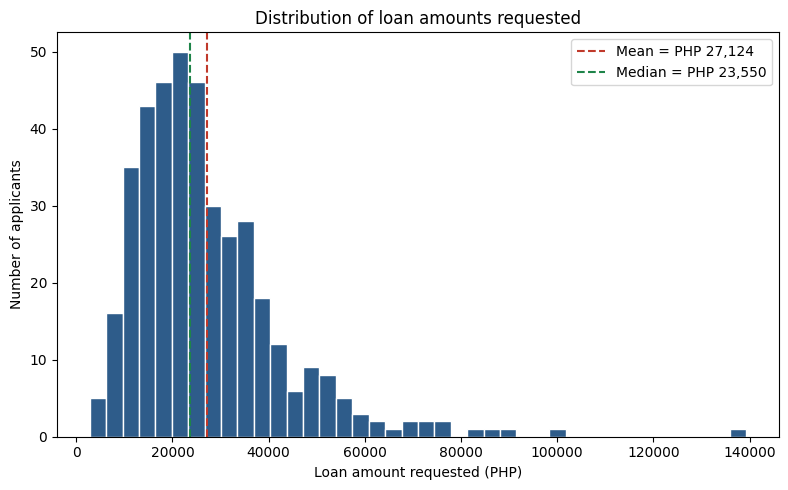

In [3]:
# TODO: verify the by-hand skewness on the four-point example
loan_example = np.array([15000, 18000, 20000, 55000.0])

# TODO: compute and print skewness with stats.skew(..., bias=False)
print("By-hand check -- skewness (adjusted):", stats.skew(loan_example, bias=False))

# TODO: compute skewness, excess kurtosis, and the Shapiro-Wilk test on the
# full loan_amount_requested_php column
loanable_amt = applicants["loan_amount_requested_php"].dropna()

mean_loanable_amt = loanable_amt.mean()
median_loanable_amt = loanable_amt.median()
skew_raw = stats.skew(loanable_amt, bias=False)
kurt_raw = stats.kurtosis(loanable_amt, bias=False)

print(f"n (non-missing) = {len(loanable_amt)}")
print(f"Mean loanable amt   = PHP {mean_loanable_amt:,.0f}")
print(f"Median loanable amt = PHP {median_loanable_amt:,.0f}")
print(f"Skewness      = {skew_raw:.2f}")
print(f"Excess kurtosis = {kurt_raw:.2f}")

shapiro_stat, shapiro_p = stats.shapiro(loanable_amt)
n_full = len(loanable_amt)
se_skew = np.sqrt(6 / n_full)
se_kurt = np.sqrt(24 / n_full)
z_skew = skew_raw / se_skew
z_kurt = kurt_raw / se_kurt

print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.2e}")
print(f"z_skew = {z_skew:.1f}, z_kurt = {z_kurt:.1f}")

# TODO: plot a histogram of loan_amount_requested_php with the mean and
# median marked as vertical lines
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(loanable_amt, bins=40, color="#2E5C8A", edgecolor="white")
ax.axvline(mean_loanable_amt, color="#C0392B", linestyle="--", label=f"Mean = PHP {mean_loanable_amt:,.0f}")
ax.axvline(median_loanable_amt, color="#1E8449", linestyle="--", label=f"Median = PHP {median_loanable_amt:,.0f}")
ax.set_xlabel("Loan amount requested (PHP)")
ax.set_ylabel("Number of applicants")
ax.set_title("Distribution of loan amounts requested")
ax.legend()
plt.tight_layout()
plt.show()

### Item 2 — Diagnosing the Missingness Pattern in Months Employed (10 pts)

The `months_employed_reported` column has some missing values. Unlike `monthly_income_php` in lecture, you do not yet know whether this missingness is related to `employment_type` or not.

**(a) Concept (3 pts).** State, in your own words, the difference between MCAR and MAR missingness, and explain what evidence would let you tell them apart using only the columns available in this dataset.

**(b) By hand (4 pts).** Six mini-applicants and their reported months employed:

| Applicant | Employment Type | Months Employed |
|---|---|---|
| 1 | Formal | 24 |
| 2 | Formal | — |
| 3 | Informal | 40 |
| 4 | Informal | 12 |
| 5 | Formal | 60 |
| 6 | Informal | — |

Compute the mean months employed for each employment type using only the non-missing values, and the overall mean using only the non-missing values. Based on which applicants are missing (applicant 2 is Formal, applicant 6 is Informal — one from each group), explain whether this small example looks more consistent with MCAR or MAR, and why.

**(c) Code (3 pts).** Run a chi-square test of independence between `employment_type` and whether `months_employed_reported` is missing, on the full dataset. Based on the test result, decide whether to drop the missing rows or impute them, implement your chosen treatment, and confirm no missing values remain.

---
a. MCAR or Missing Completely At Random, the blanks happen totally by chance. Missingness is pure chance or random accidents. The missingness don't depend on anything in the dataset.
While MAR or Missing At Random, the missing values or the blanks are not random. They are linked to something we can see in the data. It could be that the missingness follows a pattern tied to other columns you already have.

---

- Mean (Formal): $\bar{x} = \dfrac{24+60}{2} = 42$

- Mean (Informal): $\bar{x} = \dfrac{40+12}{2} = 26$

- Mean (Overall): $\bar{x} = \dfrac{24+60+40+12}{4} = 34$

There is no clear evidence that missingness is tied to employment type because the mikssing values are spread across both employment types and the missing values look like random accidents. With this, I can say that the tiny sample we have above looks more conistent with MCAR. 




In [10]:
# TODO: verify the by-hand group means on the six-row mini example
mini = pd.DataFrame({
    "employment_type": ["Formal", "Formal", "Informal", "Informal", "Formal", "Informal"],
    "months_employed": [24, np.nan, 40, 12, 60, np.nan],
})

# TODO: compute and print the group means (non-missing only) and the overall mean
mini_means = mini.groupby("employment_type")["months_employed"].mean()
print("Group means:\n", mini_means)

overall_mean = mini["months_employed"].mean()
print("\nOverall mean:", overall_mean)


# TODO: run a chi-square test of independence between employment_type and
# applicants["months_employed_reported"].isna() on the full dataset
contingency = pd.crosstab(applicants["employment_type"], applicants["months_employed_reported"].isna())
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test of independence: chi2 = {chi2:.2f}, p = {chi2_p:.2e}")

# TODO: based on your test result, implement your chosen treatment
# (drop or impute) for months_employed_reported, and confirm no missing
# values remain

# Drop missing rows
applicants_clean = applicants.dropna(subset=["months_employed_reported"])

# Confirm no missing values remain
print("Remaining missing values after grouped-median imputation:", applicants_clean["months_employed_reported"].isna().sum())  # should be 0



Group means:
 employment_type
Formal      42.0
Informal    26.0
Name: months_employed, dtype: float64

Overall mean: 34.0

Chi-square test of independence: chi2 = 0.14, p = 7.07e-01
Remaining missing values after grouped-median imputation: 0


### Item 3 — Outliers and Transformation in Requested Loan Amounts (10 pts)

This item combines two techniques: detecting outliers in `loan_amount_requested_php` and deciding how to transform what remains.

**(a) Concept (3 pts).** Explain, in your own words, why the IQR method and the z-score method can disagree about how many points are outliers when applied to a right-skewed variable like loan amount. Your answer should reference what each method is calibrated against.

**(b) By hand (4 pts).** Six hypothetical requested loan amounts (PHP), sorted: $18{,}000,\ 21{,}000,\ 23{,}500,\ 26{,}000,\ 28{,}500,\ 92{,}000$. Compute $Q_1$, $Q_3$, the IQR, and Tukey's fences. Separately compute the z-score (using the sample standard deviation, $n-1$ divisor) for the largest value. State which method(s) flag it as an outlier.

**(c) Code (3 pts).** On the full `loan_amount_requested_php` column: compute the IQR bounds and flag outliers; compute z-scores and flag any with $|z|>3$; report how many are flagged by each method and how many by both. For the points flagged by both methods, cap them at the IQR upper bound. Then log-transform the treated column and report the skewness before treatment, after treatment, and after the log transform.

---
a. On a right-skewed variable like loan amounts, the IQR method usually finds more outliers than the z-score method because each method is calibrated againts a different reference. IQR is more resistant to skew because it's based on medians and quartiles, so it tends to call more high-end values or outliers. On the other hand, z-scores are sensitive to skew because the mean and standard shift upward, so they may call fewer outliers.

---
b.
- $Q_1 = 20{,}250$, $Q_3 = 44{,}375$, so $IQR = 24{,}125$.
- Bounds: $\text{lower} = 20250 - 1.5(24125) = 15{,}937.5$, $\text{upper} = 44375 + 1.5(24125) = 80{,}562.5$.
- Only $92{,}000$ falls outside $[20{,}250,\ 44{,}375]$ — flagged by the IQR method.
- Mean $\bar{x} = 34{,}833.3$, standard deviation $s \approx 27{,}500$ (sample, $n-1$ divisor); the z-score for the largest value is $z = \dfrac{92000 - 34833.3}{27500} \approx 2.08$.

Using the IQR method, 92000 is flagged as an outlier. Since the z-score $|z| \approx 2.08$, 92000 is also flagged by the z-score method. 




In [20]:
# TODO: verify the by-hand IQR bounds and z-score on the six-point example
loan_outlier_example = np.array([18000, 21000, 23500, 26000, 28500, 92000.0])


# TODO: compute Q1, Q3, IQR, and Tukey's fences
q1_ex, q3_ex = np.percentile(loan_outlier_example, [25, 75])
iqr_ex = q3_ex - q1_ex
lower_ex, upper_ex = q1_ex - 1.5 * iqr_ex, q3_ex + 1.5 * iqr_ex

print(f"Q1 = {q1_ex}, Q3 = {q3_ex}, IQR = {iqr_ex}")
# TODO: compute the z-score of the largest value (sample std, ddof=1)


# TODO: on the full loan_amount_requested_php column, flag outliers by the
# IQR method and by the z-score method (|z| > 3); report counts for each
# method and for both together


# TODO: cap the applicants flagged by both methods at the IQR upper bound,
# then log-transform the result; report skewness before treatment, after
# capping, and after the log transform


Q1 = 21625.0, Q3 = 27875.0, IQR = 6250.0


## Section 2: Business Context & Reasoning

Each item presents a stakeholder scenario. For each, state an assumption where the scenario is ambiguous, apply the correct technique and interpret the result, and translate your finding into a recommendation RJ could act on. Full marks require both technical soundness and business reasoning — a technically correct answer with no business interpretation, or a business-savvy recommendation built on a technical misstep, will both fall short of full marks.

### Item 1 — A New Loan Product's Missing Debt Disclosure (15 pts)

BayaniFund is piloting a new product, the Solo Parent Livelihood Loan. The application form asks applicants to disclose any existing debt owed to informal lenders (locally known as "5-6" lenders). Early data from the pilot shows that a meaningful share of applicants leave this field blank, and RJ suspects that applicants who currently carry a lot of informal debt are exactly the ones most likely to skip the question, since disclosing it could hurt their approval odds.

State the assumption you're making about why this field is missing, explain what missingness mechanism this scenario describes and why the standard treatment strategies from this week (dropping, or imputing from an observed variable) would each fail to fix it properly, and give RJ a concrete recommendation for how to handle this field in the credit-scoring pipeline.

**Point split:** technical soundness (identifying the correct missingness mechanism and explaining why standard treatments fail) — 8 pts; business reasoning (a recommendation RJ could actually implement) — 7 pts.

---
**WRITE YOUR TEXT ANSWERS HERE**

*double-click this part*

---





&nbsp;

### Item 2 — Evaluating a Proposed Fraud Filter (15 pts)

A junior loan officer proposes a simple rule to catch fraudulent income declarations: "Let's automatically reject any applicant whose income z-score is above 2." RJ asks you to evaluate this proposal before it goes into production.

State any assumption you need about how the rule would be implemented, evaluate the proposal technically (consider how z-scores behave on a right-skewed variable like income, and what threshold and treatment choices this week's material would actually support), evaluate it from a business-risk standpoint (consider who would be affected by an automatic rejection, not just a flag), and give RJ a specific recommendation — including whether "auto-reject" is the right action at all.

**Point split:** technical soundness (correctly diagnosing the flaws in the proposed rule) — 8 pts; business reasoning (weighing the impact on legitimate applicants and proposing a workable alternative) — 7 pts.

---
**WRITE YOUR TEXT ANSWERS HERE**

*double-click this part*

---





## Citation Reminder

All external sources used in this assignment — textbooks, papers, articles, code snippets, and any generative AI tool use — must be cited per course policy.

## References